Playing around and testing [notes](https://cdds-uiuc.github.io/note-book/content/Hasselmann/Hasselmann.html) written by Cristi Proistosescu about the Hasselmann model

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from multitaper import mtspec
from scipy import stats

## white noise

Notes: changing the timescale dt changes the power spectral density (should be constant at one number) even though the stationary variance is the same. This indicates one of the challenges of simulating white noise.

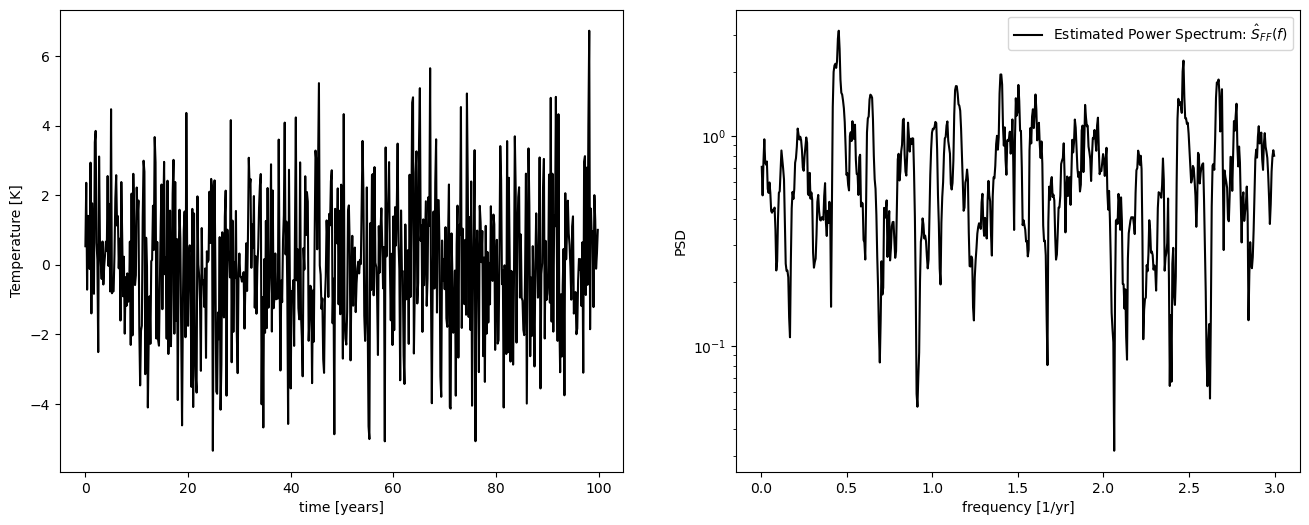

In [ ]:
# Set parameters
dt=1/12;     #time-scale. Let's say time is in years, and the time-step is 1 month, so 1/12 years.
T=100        # total integration time [years]
sigma_F=2    # variance of the forcing

# time-vector
t=np.arange(0,T,dt)
N=len(t)

#sample a gaussian white noise process (each F_n is independent and identically distributed, or i.i.d.).
F=stats.norm.rvs(loc=0,scale=sigma_F,size=N)

# Compute the spectral estimates
out=mtspec.MTSpec(F,nw=3,dt=dt,kspec=3)
f=out.freq       # freuencies
S_FF=out.spec    # power spectra
S_FF=S_FF[f>0]         # keep positive frequencies
f=f[f>0]

#Plots
plt.figure(figsize=[16,6]);
plt.subplot(1,2,1)
plt.plot(t,F,'k')
plt.xlabel('time [years]')
plt.ylabel('Temperature [K]')

plt.subplot(1,2,2)
plt.plot(f,S_FF,'k',label=r'Estimated Power Spectrum: $\hat S_{FF}(f)$')

plt.xscale('linear')
plt.yscale('log')
plt.xlabel('frequency [1/yr]')
plt.ylabel('PSD')
plt.legend()

## simple Hasselmann model

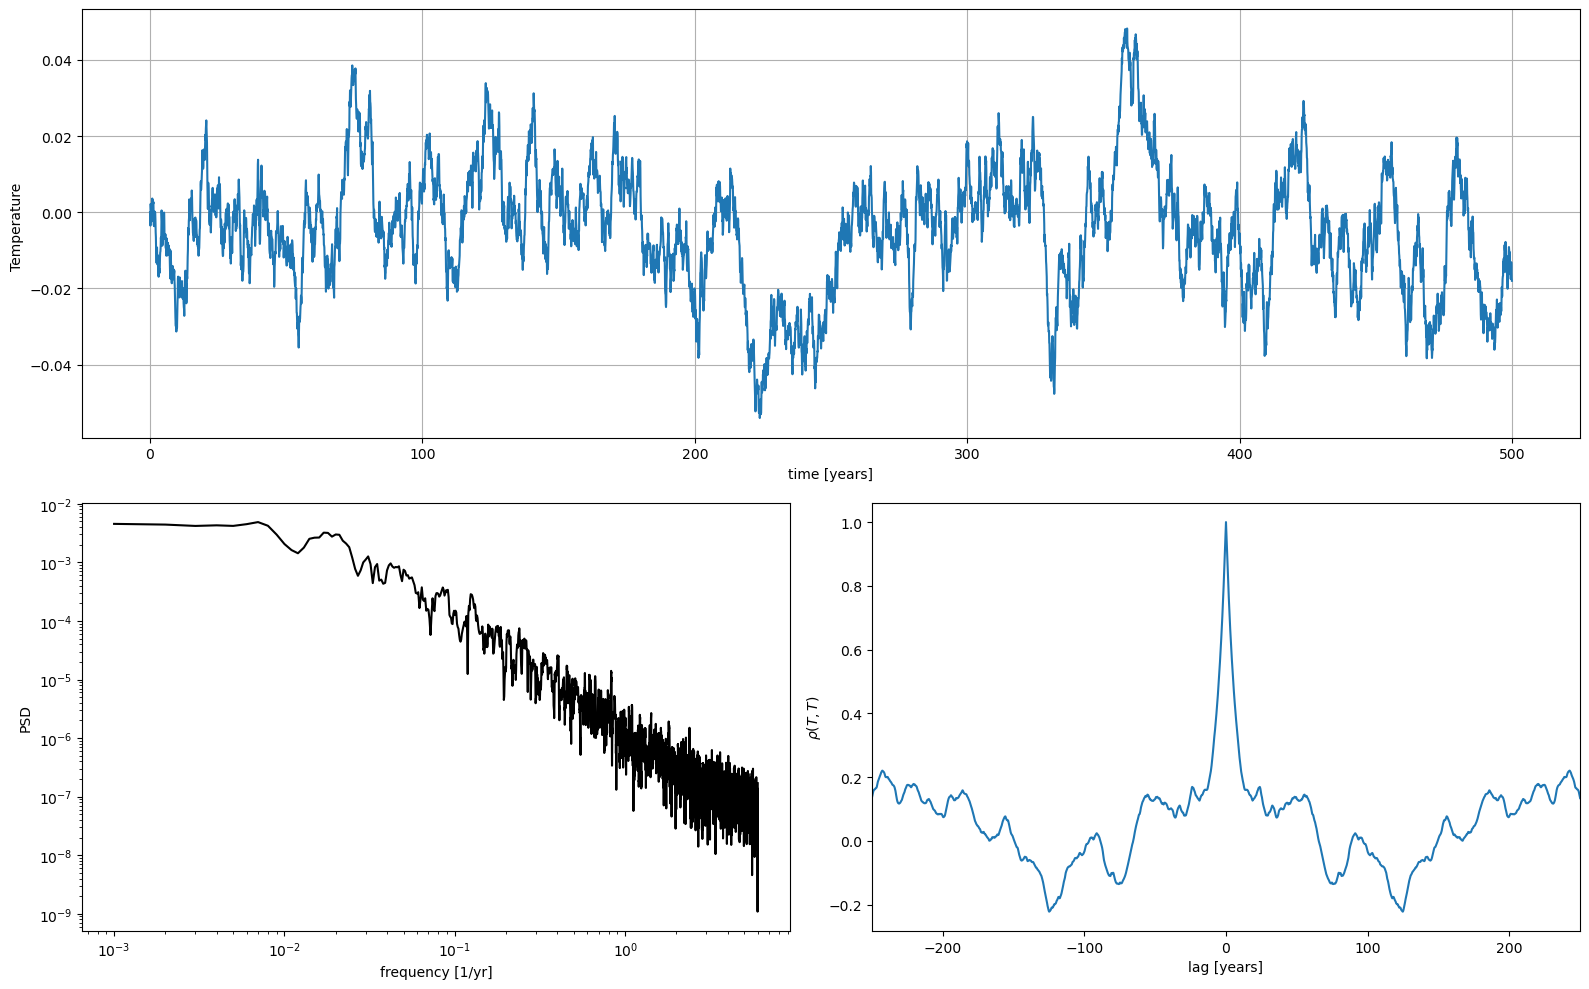

In [15]:
dt=1/12;     #time-scale. Let's say time is in years, and the time-step is 1 month, so 1/12 years.
T=500        # total integration time [years]
sigma_F=2    # variance of the forcing
tau_0= 10       # time-scale tau=C/lambda [years]
lam= 7       # feedback lambda

# time-vector
t=np.arange(0,T,dt)
N=len(t)

#sample a gaussian white noise process (each F_n is independent and identically distributed, or i.i.d.).
F=stats.norm.rvs(loc=0,scale=sigma_F,size=N)

# calculate phi and eps for the discretization
phi=   1-dt/tau_0
eps = (dt/tau_0/lam)*F;

## Simulate the Hasselmann model
#pre-allocate
T=np.zeros(N)

for n in range(1,N):
    T[n]=phi*T[n-1]+eps[n]

out=mtspec.MTSpec(T,nw=3,dt=dt,kspec=3)
f=out.freq
S_TT=out.spec
S_TT=S_TT[f>0]
f=f[f>0]

# Plots

plt.figure(figsize=[16,10]);

plt.subplot(2,1,1)
    
plt.plot(t,T,'-')
plt.grid()
plt.xlabel('time [years]')
plt.ylabel('Temperature ')

plt.subplot(2,2,3)
plt.plot(f,S_TT,'k',label=r'Estimated Power Spectrum: $\hat S_{FF}(f)$')

plt.xlabel('frequency [1/yr]')
plt.ylabel('PSD')

plt.xscale('log')
plt.yscale('log')

# Plot autocorrelation function
plt.subplot(2,2,4)

acf=np.correlate(T,T,mode='full')
acf=acf/np.max(acf)
lags=np.arange(-N+1,N)

plt.plot(lags*dt,acf)
plt.xlabel('lag [years]')
plt.ylabel(r'$\rho(T,T)$')

plt.xlim(-N*dt/2,N*dt/2)

plt.tight_layout()